# GW waveform and Basic parameter estimation Tutorial

This is a notebook to follow along for the **"PE and waveform generation"** session.

Link to the slide: [Google Drive](https://drive.google.com/file/d/1oNofzqlbfmuXGQM1ULfUgetWfH-7EiJb/view?usp=sharing)

<b style=color:red>Disclaimer: This notebook is intended to run on the workstation, using the conda environment `Summer2026-py311`. </b>

Efforts have been made to accomodate users running locally, but some cells may still not work properly without the necessary data.

<!-- There is a conda environment `Summer2026-py311` that has been prepared for this. -->

In [1]:
# Basic imports
from pathlib import Path
import os
import socket
from copy import deepcopy 
import numpy as np
import matplotlib.pyplot as plt

# For local users, please make sure this flag is set to True.
LOCAL_USER = True
if  "phy.cuhk.edu.hk" in socket.getfqdn():
    LOCAL_USER = False
# Whether to run the full PE which will take more than 20 minutes to complete.
RUN_FULL_PE = False
# This is needed for the NRSurrogate waveform model
os.environ["LAL_DATA_PATH"] = "/users/shared.user/lscsoft/lalsuite-waveform-data/waveform_data"

# For disabling LALSuite warning messages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

outdir = Path('./figures')
outdir.mkdir(exist_ok=True)
datadir = Path('./data')
datadir.mkdir(exist_ok=True)

print("Please check the following options are correct:")
print(f"\t* Running on {socket.getfqdn()}, with:\n\t* {LOCAL_USER = }, \n\t* {RUN_FULL_PE = }")


Please check the following options are correct:
	* Running on tgfli-s0.phy.cuhk.edu.hk, with:
	* LOCAL_USER = False, 
	* RUN_FULL_PE = False


In [2]:
if not LOCAL_USER:
    cvmfs_dir = Path('/cvmfs/gwosc.osgstorage.org/gwdata/')
    strain_data = cvmfs_dir / 'O1/strain.16k/frame.v1/'
    gwtc2p1_dir = cvmfs_dir / 'zenodo/ligo-virgo-kagra/2022/6513631/'
    samples_indir = Path('/users/shared.user/Summer2026/SummerSchool2026')
else:
    strain_data = datadir
    gwtc2p1_dir = datadir
    samples_indir = datadir
    import download_open_data

In [3]:
# Import bilby and gwpy
from bilby import run_sampler
from bilby.core.utils import logger
from bilby.core.prior import Uniform, Cosine, PowerLaw
from bilby.gw.waveform_generator import WaveformGenerator
from bilby.gw.detector import InterferometerList, PowerSpectralDensity
from bilby.gw.source import lal_binary_black_hole
from bilby.gw.conversion import \
    convert_to_lal_binary_black_hole_parameters, generate_all_bbh_parameters
from bilby.gw.prior import BBHPriorDict
from bilby.gw.likelihood import GravitationalWaveTransient
from bilby.gw.result import CBCResult
from gwpy.timeseries import TimeSeries
from pesummary.io import read

from extrinsic_likelihood import SimpleExtrinsicGWTransient

# Update plt plotting style
# Only load this after the gwpy import (otherwise would be overwritten)
plt.style.use("../matplotlibrc")

## Gravitational waves waveform

In this section, we first have a look at how to generate a GW waveform using the standard analysis package employed in LIGO –– `Bilby`.

We will also look at how different binary parameters would affect the waveform morphologies. 

Then, we will explore how different waveform models, constructed from several different physical foundations, would affect some details in the waveforms. 
Especically when it comes to more asymmetric binaries.

In [4]:
duration = 4.0  # s
sampling_frequency = 4096.0  # Hz
minimum_frequency = 20.0  # Hz
reference_frequency = 50.0  # Hz
geocent_time = 1126259462.4  # s

# Parameters similar to the first GW signal –– GW150914
gw150914_parameters = dict(
    total_mass=66.0,
    mass_ratio=30.0/35.0,
    a_1=0.4,
    a_2=0.3,
    tilt_1=0.5,
    tilt_2=1.0,
    phi_12=1.7,
    phi_jl=0.3,
    luminosity_distance=470.0,
    theta_jn=2.4,
    psi=2.65,
    phase=1.3,
    geocent_time=geocent_time,
    ra=1.375,
    dec=-1.2108,
)

# waveform generator
wfm_gen = WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=lal_binary_black_hole,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=dict(
        waveform_approximant="IMRPhenomXPHM",
        reference_frequency=reference_frequency
    ),
)

16:25 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


### Effect of changing different binary parameters on the waveform

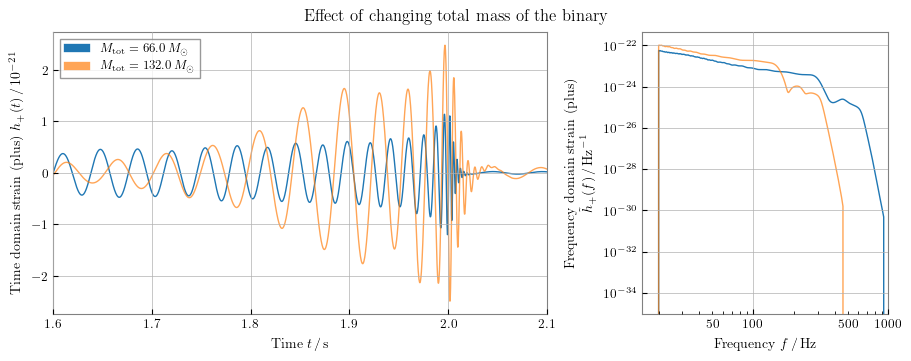

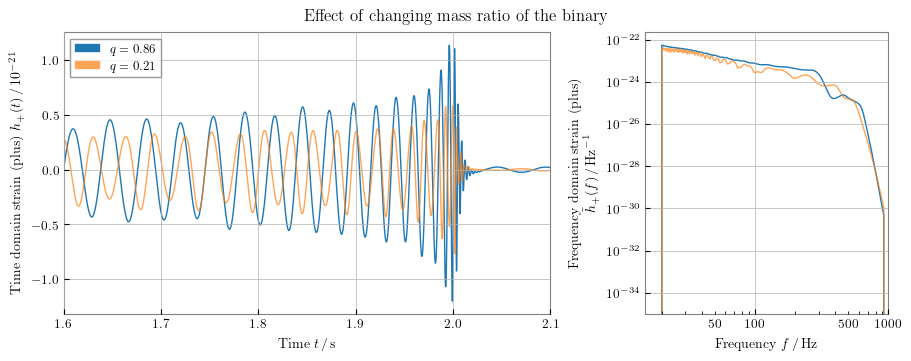

In [5]:
def plot_waveform(wfm_gen, parameters, axes, **plot_kwargs):
    wfm_gen.parameters = parameters
    gw_hpc_td = wfm_gen.time_domain_strain()
    gw_strain_td = gw_hpc_td['plus']
    gw_strain_td_abs = np.sqrt(gw_hpc_td['plus']**2 + gw_hpc_td['cross']**2)
    gw_hpc_fd = wfm_gen.frequency_domain_strain()
    gw_strain_fd = gw_hpc_fd['plus']

    ## Time-domain
    ax = axes[0]
    ax.plot(wfm_gen.time_array,
            np.roll(gw_strain_td, int(duration * sampling_frequency/2)) * 1e21, **plot_kwargs)
    ax.set_xlabel(r'Time $t\,/\,{\rm s}$')
    ax.set_ylabel(r'Time domain strain (plus) $h_+(t)\,/\,10^{-21}$')
    ## Frequency-domain
    ax = axes[1]
    ax.loglog(wfm_gen.frequency_array, np.abs(gw_strain_fd), **plot_kwargs)
    ax.set_xlabel(r'Frequency $f\,/\,{\rm Hz}$')
    ax.set_ylabel("Frequency domain strain (plus)\n" +  r'$\tilde h_+(f)\,/\,{\rm Hz}^{-1}$')

    if len(axes) > 2:
        ax = axes[2]
        ax.plot(wfm_gen.time_array, 
            np.roll(gw_strain_td_abs, int(duration * sampling_frequency/2)) * 1e21, **plot_kwargs)
        ax.set_xlabel(r'Time $t\,/\,{\rm s}$')
        ax.set_ylabel(r'Time domain strain amplitude $|h(t)|\,/\,10^{-21}$')

    return gw_hpc_td, gw_hpc_fd


wfm_gen.parameters = gw150914_parameters

fig1, axes1 = plt.subplots(1, 2, figsize=(9, 3.5),
                         width_ratios=[2, 1], constrained_layout=True)
fig1.suptitle('Effect of changing total mass of the binary')
fig2, axes2 = plt.subplots(1, 2, figsize=(9, 3.5),
                         width_ratios=[2, 1], constrained_layout=True)
fig2.suptitle('Effect of changing mass ratio of the binary')

# Plot the original waveform first
for axes in (axes1, axes2):
    ## Time-domain
    plot_waveform(wfm_gen, gw150914_parameters, axes)

    axes[0].set_xlim(1.6, 2.1)
    axes[1].set_xlim(15, 1000)

## Varying the parameters
### Update masses
massive_bbh = gw150914_parameters.copy()
massive_bbh['total_mass'] *= 2.0  # 66 * 2 = 132
wfm_gen.parameters = massive_bbh
plot_waveform(wfm_gen, massive_bbh, axes1, alpha=0.7)
axes1[0].legend(labels=[
    fr'$M_{{\rm tot}} = {gw150914_parameters["total_mass"]:.1f}\,M_\odot$',
    fr'$M_{{\rm tot}} = {massive_bbh["total_mass"]:.1f}\,M_\odot$'])

### Update the mass ratio.
asymmetric_bbh = gw150914_parameters.copy()
asymmetric_bbh['mass_ratio'] /= 4.0
wfm_gen.parameters = asymmetric_bbh
plot_waveform(wfm_gen, asymmetric_bbh, axes2, alpha=0.7)

axes2[0].legend(labels=[
    fr'$q = {gw150914_parameters["mass_ratio"]:.2f}$',
    fr'$q = {asymmetric_bbh["mass_ratio"]:.2f}$'])

fig1.savefig(outdir / 'effect_of_total_mass_on_waveform.pdf')
fig2.savefig(outdir / 'effect_of_mass_ratio_on_waveform.pdf')

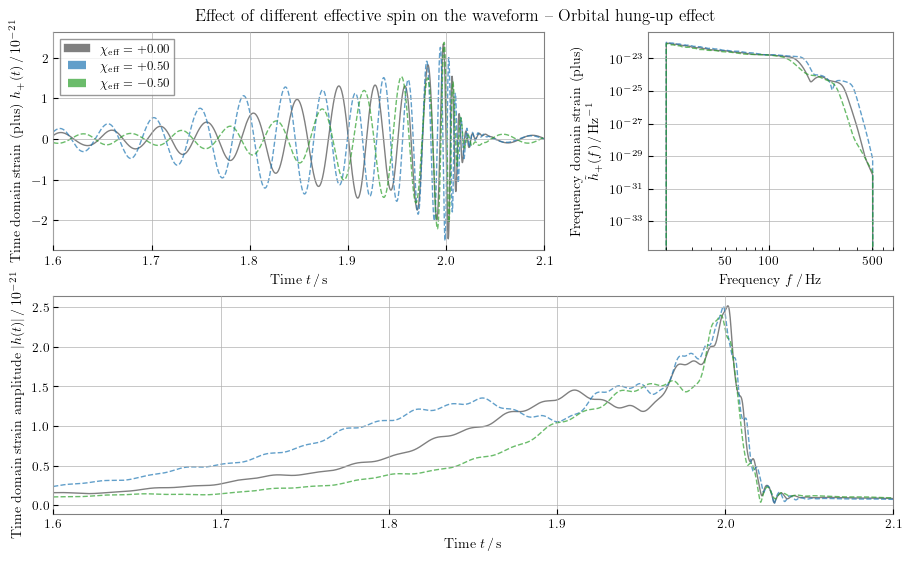

In [6]:
def compute_chi_eff(parameters):
    spin_1z = parameters['a_1'] * np.cos(parameters['tilt_1'])
    spin_2z = parameters['a_2'] * np.cos(parameters['tilt_2'])
    if 'mass_ratio' in parameters:
        mass_ratio = parameters['mass_ratio']
    else:
        mass_ratio = parameters['mass_2'] / parameters['mass_1']
    chi_eff = (spin_1z + mass_ratio * spin_2z) / (1 + mass_ratio)
    return chi_eff

fig = plt.figure(figsize=(9, 5.5))
Axes = fig.subplot_mosaic( [ ["td", "fd"], ["abs", "abs"], ], width_ratios=[2, 1])
axes = list(Axes.values())
fig.suptitle('Effect of different effective spin on the waveform -- Orbital hung-up effect')

zero_spin_bbh = gw150914_parameters.copy()
zero_spin_bbh['total_mass'] = 120.0  
zero_spin_bbh['a_1'] = 0.0
zero_spin_bbh['a_2'] = 0.0
zero_spin_bbh['tilt_1'] = 0.0
zero_spin_bbh['tilt_2'] = 0.0
zero_spin_bbh['phi_12'] = 0.0
zero_spin_bbh['phi_jl'] = 0.0
plot_waveform(wfm_gen, zero_spin_bbh, axes, c='grey')

align_spin_bbh = zero_spin_bbh.copy()
align_spin_bbh['a_1'] = 0.5
align_spin_bbh['a_2'] = 0.5
plot_waveform(wfm_gen, align_spin_bbh, axes, alpha=0.7, ls='--')

anti_align_spin_bbh = align_spin_bbh.copy()
anti_align_spin_bbh['tilt_1'] = np.pi
anti_align_spin_bbh['tilt_2'] = np.pi
plot_waveform(wfm_gen, anti_align_spin_bbh, axes, alpha=0.7, ls='--', c='C2')

axes[0].legend(labels=[
    fr'$\chi_{{\rm eff}} = {compute_chi_eff(params):+.2f}$' 
    for params in [zero_spin_bbh, align_spin_bbh, anti_align_spin_bbh]
])

axes[0].set_xlim(1.6, 2.1)
axes[2].set_xlim(1.6, 2.1)
axes[1].set_xlim(15, 700)

fig.savefig(outdir / 'effect_of_chi_eff_on_waveform.pdf')

Observe from the amplitude plot, it is clear that the blue curve is the longest amongst them. 
In the case with positively aligned spin, it takes more time to emit the excess angular momentum from the spins, and hence resulted in a longer waveform than the zero-spin case. 
Similarly, the anti-aligned spin case has less total angular momentum than the zero-spin case, and therefore a shorter waveform. 

This is known as the orbital hung-up effect.



### Comparing different waveform models

16:25 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
16:25 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
16:25 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


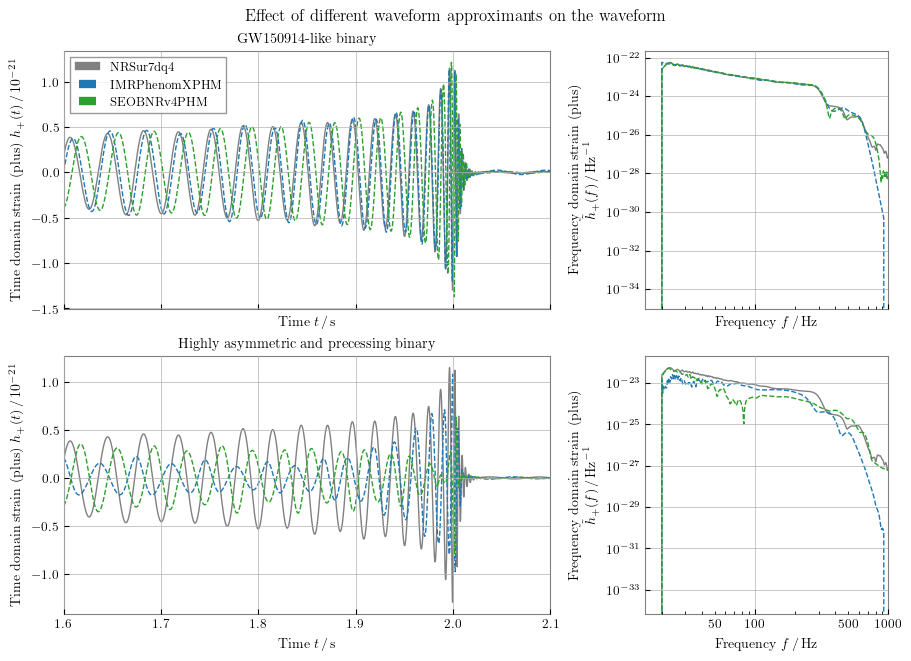

In [7]:
wfm_kwargs = dict(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=lal_binary_black_hole,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=dict(
        waveform_approximant="IMRPhenomXPHM",
        reference_frequency=reference_frequency
    ),
)
# waveform generator
xphm_gen = WaveformGenerator(**wfm_kwargs)

nrsur_kwargs = deepcopy(wfm_kwargs)
nrsur_kwargs['waveform_arguments']['waveform_approximant'] = "NRSur7dq4"
nrsur_gen = WaveformGenerator(**nrsur_kwargs)

seob_kwargs = deepcopy(wfm_kwargs)
seob_kwargs['waveform_arguments']['waveform_approximant'] = "SEOBNRv4PHM"
seob_gen = WaveformGenerator(**seob_kwargs)

asymmetric_high_spin_bbh = gw150914_parameters.copy()
asymmetric_high_spin_bbh['mass_ratio'] = 1 / 4
asymmetric_high_spin_bbh['a_1'] = 0.9
asymmetric_high_spin_bbh['a_2'] = 0.5
asymmetric_high_spin_bbh['tilt_1'] = 2.1
asymmetric_high_spin_bbh['tilt_2'] = 1.4
asymmetric_high_spin_bbh['phi_12'] = 3.1
asymmetric_high_spin_bbh['phi_jl'] = 4.1


fig, Axes = plt.subplots(2, 2, figsize=(9, 6.5), sharex='col',
                         width_ratios=[2, 1], constrained_layout=True)
fig.suptitle('Effect of different waveform approximants on the waveform')
axes = Axes[0]
if not LOCAL_USER:
    plot_waveform(nrsur_gen, gw150914_parameters, axes, c='grey', label='NRSur7dq4')
plot_waveform(xphm_gen, gw150914_parameters, axes, c='C0', ls='--', label='IMRPhenomXPHM')
plot_waveform(seob_gen, gw150914_parameters, axes, c='C2', ls='--', label='SEOBNRv4PHM')
axes[0].legend()
axes[0].set_xlim(1.6, 2.1)
axes[1].set_xlim(15, 1000)
axes[0].set_title('GW150914-like binary')

axes = Axes[1]
if not LOCAL_USER:
    plot_waveform(nrsur_gen, gw150914_parameters, axes, c='grey', label='NRSur7dq4')
plot_waveform(xphm_gen, asymmetric_high_spin_bbh, axes, c='C0', ls='--', label='IMRPhenomXPHM')
plot_waveform(seob_gen, asymmetric_high_spin_bbh, axes, c='C2', ls='--', label='SEOBNRv4PHM')
axes[0].set_title('Highly asymmetric and precessing binary')

fig.savefig(outdir / 'effect_of_approximant_on_waveform.pdf')

Different waveform models have different physical assumptions and definitions of the binary parameters. 

What they then do is to map their own definitions to the canonical ones, and the biggest differences is in the phase.

* NRSur7dq4
  * it is a model fitting directly the NR simulations, which contains the most physics, but it has its own limitations. 

* Phenom family
  * its basis is the post-Newtonian formalism, which assumes 1) there are **two** bodies, and 2) the centre of mass of the binary is stationary, which is not true in general. 
That said, there are some additional procedures done to mitigate the inaccuracies from these assumptions.

* SEOB family 
  * it is based on the so-called "effective-one-body" formalism, so instead of considering two moving bodies, it models the binary as one test particle moving in an effective metric. 

All in all, each of these models have their own advantages and drawbacks, generally, in terms of physical accuracy, the order goes as: **NRSurrogate** > **SEOB** > **Phenom**.

This is why in the case of the simplest vanilla binary, the event GW150914, all three of them give a similar waveform, other than minor phase difference.
Huge discrepancy enters in the case of more extreme binaries, not only because this is stretching the limit of the models, but also it is the least callibrated region. 

## Gravitational wave strain data
<!--
## Noise on detector data and models on generated waveform

In [8]:
# Initialise a detector network
ifos = InterferometerList(['H1', 'L1', 'V1'])

O4_sens = ('aLIGO_O4_high_asd.txt', 'AdV_asd.txt')
gen3_sens = ('CE_wb_asd.txt', 'ET_D_asd.txt')

set_strain_kwargs = dict(sampling_frequency=sampling_frequency, duration=duration, start_time=geocent_time - 2)
inject_kwargs = dict(waveform_generator=wfm_gen, parameters=gw150914_parameters)

wh_strains_dict = {}

def save_to_dict(name, ifos, strain_dict=wh_strains_dict):
    strain_dict[f'{name}_td'] = {ifo.name: ifo.whitened_time_domain_strain for ifo in ifos}
    strain_dict[f'{name}_fd'] = {ifo.name: ifo.whitened_frequency_domain_strain for ifo in ifos}
    strain_dict[f'{name}_opt_snr'] = np.sqrt(np.sum([ifo.meta_data['optimal_SNR']**2 for ifo in ifos]))
    strain_dict[f'{name}_mf_snr'] = np.sqrt(np.sum([ifo.meta_data['matched_filter_SNR']**2 for ifo in ifos]))

for name, sens in zip(
    ('o4', '3gen'), (O4_sens, gen3_sens)
):
    for ifo in ifos:
        if ifo.name == 'V1':
            ifo.power_spectral_density = PowerSpectralDensity(asd_file=sens[1])
        else:
            ifo.power_spectral_density = PowerSpectralDensity(asd_file=sens[0])

    # Zero-noise
    ifos.set_strain_data_from_zero_noise(**set_strain_kwargs)
    ifos.inject_signal(**inject_kwargs)
    save_to_dict(name+'_zn', ifos)

    ## Clear the stored strain data
    ifos.set_strain_data_from_zero_noise(**set_strain_kwargs)
    ifos.set_strain_data_from_power_spectral_densities(**set_strain_kwargs)
    ifos.inject_signal(**inject_kwargs)
    save_to_dict(name, ifos)

16:26 bilby INFO    : Injected signal in H1:
16:26 bilby INFO    :   optimal SNR = 41.81
16:26 bilby INFO    :   matched filter SNR = 41.81+0.00j
16:26 bilby INFO    :   total_mass = 66.0
16:26 bilby INFO    :   mass_ratio = 0.8571428571428571
16:26 bilby INFO    :   a_1 = 0.4
16:26 bilby INFO    :   a_2 = 0.3
16:26 bilby INFO    :   tilt_1 = 0.5
16:26 bilby INFO    :   tilt_2 = 1.0
16:26 bilby INFO    :   phi_12 = 1.7
16:26 bilby INFO    :   phi_jl = 0.3
16:26 bilby INFO    :   luminosity_distance = 470.0
16:26 bilby INFO    :   theta_jn = 2.4
16:26 bilby INFO    :   psi = 2.65
16:26 bilby INFO    :   phase = 1.3
16:26 bilby INFO    :   geocent_time = 1126259462.4
16:26 bilby INFO    :   ra = 1.375
16:26 bilby INFO    :   dec = -1.2108
16:26 bilby INFO    : Injected signal in L1:
16:26 bilby INFO    :   optimal SNR = 33.59
16:26 bilby INFO    :   matched filter SNR = 33.59-0.00j
16:26 bilby INFO    :   total_mass = 66.0
16:26 bilby INFO    :   mass_ratio = 0.8571428571428571
16:26 bil

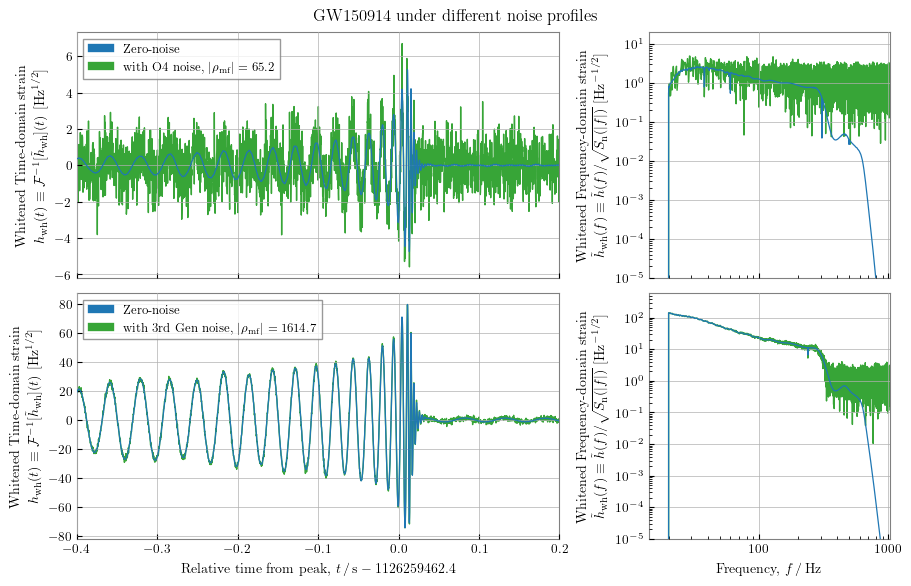

In [9]:
fig, Axes = plt.subplots(2, 2, figsize=(9, 5.75), sharex='col',
                         width_ratios=[2, 1], constrained_layout=True)

zn_kwargs = {'lw': 0.9, 'zorder': 10, 'label': 'Zero-noise'}

for axes, name, label in zip(Axes, ('o4', '3gen'), ('O4', '3rd Gen')):
    ax = axes[0]
    ax.plot(ifos[0].time_array - geocent_time, wh_strains_dict[f'{name}_zn_td']['H1'], **zn_kwargs)
    ax.plot(ifos[0].time_array - geocent_time, wh_strains_dict[f'{name}_td']['H1'],
            label=fr'with {label} noise, $|\rho_{{\rm mf}}| = {np.abs(wh_strains_dict[f"{name}_mf_snr"]):.1f}$',
            alpha=.95, c='C2')
    ax.legend()
    ax = axes[1]
    ax.loglog(ifos[1].frequency_array, np.abs(wh_strains_dict[f'{name}_zn_fd']['H1']), **zn_kwargs)
    ax.loglog(ifos[1].frequency_array, np.abs(wh_strains_dict[f'{name}_fd']['H1']),
              alpha=.95, c='C2')

for ax in Axes[:, 0]:
    ax.set_ylabel("Whitened Time-domain strain\n" + r'$h_{\rm wh}(t) \equiv {\cal F}^{-1}[\tilde h_{\rm wh}](t)\ [{\rm Hz}^{1/2}]$')
    ax.set_xlim(-0.4, +0.2)
for ax in Axes[:, 1]:
    ax.set_ylabel("Whitened Frequency-domain strain\n" + r'$\tilde{h}_{\rm wh}(f) \equiv \tilde{h}(f)/\sqrt{S_{\rm n}(|f|)}\ [{\rm Hz}^{-1/2}]$')
    ax.set_xlim(14, 1024)
    ax.set_ylim(bottom=1e-5)

Axes[1, 0].set_xlabel(fr'Relative time from peak, $t\,/\,{{\rm s}} - {geocent_time:.1f}$')
Axes[1, 1].set_xlabel(r'Frequency, $f\,/\,{\rm Hz}$')
fig.suptitle('GW150914 under different noise profiles')
fig.savefig(outdir / 'different_noises.pdf')

Same signal, but they appear completely differnetly under different detector sensitivities!

## Public strain data

All public data of past events can be found here: [GWOSC](https://gwosc.org/eventapi/html/GWTC/)

There are different ways to obtain these data.

1. Through the web-interface, and download them from there
2. On the workstation, all strain data (and posterior samples) can be found under the `/cvmfs/`
3. Use `TimeSeries.fetch_open_data`



## Interacting with posterior samples
<!--  Read poterior samples and plot distributions -->

In this section, we will have a look at the posterior samples of another famous event -- GW231123. 

This event was known for its being the most massive BHs (at the time) and therefore a relative short signal, making it a challenging task for the analysis.

We will use two different packages to interact with its samples:
* `bilby` -- the analysis package itself; and
* `pesummary` -- the package designed for interacting with and unifying posterior samples from different analysis pipelines.

### Reading with `Bilby`

In [10]:
if LOCAL_USER:
    print("Bilby results not available, skipping.")
else:
    full_result = CBCResult.from_hdf5(samples_indir / 'S231123cg_bilby_NRSur7dq4_merge_result.hdf5')


16:26 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


### Reading with `PESummary`

In [11]:
# This file may take a while to load.
published_result = read(samples_indir / "S231123cg_discovery_pesummary.hdf5", package='gw')

# It contains results from several waveform models, we will focus on the NRSur7dq4 here:
print("The published result contains the following waveform models:\n\t" + ", ".join(published_result.samples_dict.keys()))

print("These are the other attributes in this result object:\n\t" +
       ", ".join([attr for attr in published_result.__dict__.keys() if not attr.startswith('_')]))

published_nrsur_result = published_result.samples_dict['C00:NRSur7dq4']

/opt/conda/envs/Summer2026-py311/lib/python3.11/site-packages/pycbc/inference/models/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import iter_entry_points as _iter_entry_points


lal.MSUN_SI != Msun


The published result contains the following waveform models:
	C00:IMRPhenomTPHM, C00:IMRPhenomXO4a, C00:IMRPhenomXPHM-SpinTaylor, C00:Mixed, C00:NRSur7dq4, C00:SEOBNRv5PHM
These are the other attributes in this result object:
	path_to_results_file, mcmc_samples, remove_nan_likelihood_samples, extension, converted_parameters, data, parameters, samples, injection_parameters, input_version, extra_kwargs, priors, analytic, labels, config, weights, history, description, approximant, psd, calibration, skymap


### Getting the maximun likelihood parameters of GW150914

In [12]:
# This is the local copy of the published result in our workstation.
gw150914_result = read(gwtc2p1_dir / 'IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo.h5', package='gw')
gw150914_mixed_poste = gw150914_result.samples_dict['C01:Mixed']

# The maximum likelihood point in the posterior samples
gw150914_maxL_params = gw150914_mixed_poste.maxL
gw150914_maxL_parameters = {key: float(gw150914_mixed_poste.maxL[key][0]) \
    for key in gw150914_parameters.keys()}

print("The maximum likelihood parameters for GW150914 are:")
for key, val in gw150914_maxL_parameters.items():
    print(f"'{key}': {val:.4f}")

2026-06-23  16:27:32 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


The maximum likelihood parameters for GW150914 are:
'total_mass': 69.7403
'mass_ratio': 0.8900
'a_1': 0.4589
'a_2': 0.6218
'tilt_1': 1.3119
'tilt_2': 1.9678
'phi_12': 2.3537
'phi_jl': 5.0662
'luminosity_distance': 402.6024
'theta_jn': 2.7477
'psi': 1.2054
'phase': 3.7198
'geocent_time': 1126259462.4264
'ra': 1.6894
'dec': -1.2409


## Parameter estimation example
<!-- ## Perform simplified PE by bilby with given detector data

The Bayes' inference

$$
p(\theta \,|\, d) = \frac{{\cal L}(d \,|\, \theta)\,\pi(\theta)}{{\cal Z}(d)}
$$

where

* $p(\theta \,|\, d)$ is the posterior distribution of $\theta$
* ${\cal L}(d \,|\, \theta)$ is the likelihood function
* $\pi(\theta)$ is the prior distribution of the parameters (before the analysis)
* ${\cal Z}(d)$ is called the evidence of the data, under our assumption

The likelihood depends on the waveform model, $h(\theta)$, specifically, given parameters $\theta$, the likelihood reads
$$
{\cal L}(d \,|\, \theta) \propto \exp\left(-\frac{1}{2}\langle d - h(\theta)\,|\,d-h(\theta)\rangle\right)\ ,
$$
where $\langle \cdot \,|\, \cdot \rangle$ is called the noise-weighted inner product.

In a GW data analysis, the goal is to obtain the posterior distribution of the BBH parameters ($\theta$) and the evidence of $d$ being a genuine GW signal.

The evidence, as a normalisation constant (of $p(\theta\,|\,d)$), can be obtained through
$$
{\cal Z}(d) = \int {\rm d}\theta\, {\cal L}(d \,|\, \theta)\,\pi(\theta)\ ,
$$
also known as the marginalised likelihood. This is a high-dimensional integration, for precessing BBH it is 15. A traditional grid-base approach to integrate this would not be computationally feasible, hence most analyses rely on stochastic integration instead.

In `bilby`, one would need to
1. prepare the data, $d$ (in the interferometer object)
2. specify the waveform model to use ($h(\theta)$)
3. set the priors, $\pi(\theta)$
4. set up the likelihood from the data and the waveform model
5. run the sampling process as a means to perform integration.

In [13]:
# IO settings
label = 'GW150914_extrinsic_pe'
pe_outdir = Path('./outdir_' + label)
pe_outdir.mkdir(exist_ok=True)

# Data conditioning
trigger_time = 1126259462.4
sampling_frequency = 1024
maximum_frequency = 512
minimum_frequency = 20
roll_off = 0.4  # Roll off duration of tukey window in seconds, default is 0.4s
duration = 4  # Analysis segment duration
post_trigger_duration = 2  # Time between trigger time and end of segment
end_time = trigger_time + post_trigger_duration
start_time = end_time - duration

## for estimating PSD from adjacent data segments
psd_duration = 32 * duration
psd_start_time = start_time - psd_duration
psd_end_time = start_time


# 1. Initialising detector network and strain data
pe_ifos = InterferometerList(['H1', 'L1'])
for ifo in pe_ifos:
    det = ifo.name
    logger.info(f"Reading analysis data for {det}")
    strain_filename = f'{det}/1126170624/{det[0]}-{det}_LOSC_16_V1-1126256640-4096.gwf' \
        if not LOCAL_USER else \
            f'{det[0]}-{det}_LOSC_16_V1-1126256640-4096.gwf'
    data = TimeSeries.read(
        strain_data / strain_filename, 
        start=start_time, end=end_time, channel=f'{det}:GWOSC-16KHZ_R1_STRAIN'
    )
    data = data.resample(sampling_frequency)
    ifo.strain_data.set_from_gwpy_timeseries(data)

    logger.info(f"Reading psd data for {det}")
    psd_data = TimeSeries.read(
        strain_data / strain_filename, 
        start=psd_start_time, end=psd_end_time, channel=f'{det}:GWOSC-16KHZ_R1_STRAIN'
    )
    psd = psd_data.psd(
        fftlength=duration, overlap=0,
        window=("tukey", 2 * roll_off / duration), method="median"
    )
    ifo.power_spectral_density = PowerSpectralDensity(
        frequency_array=psd.frequencies.value, psd_array=psd.value
    )
    ifo.maximum_frequency = maximum_frequency
    ifo.minimum_frequency = minimum_frequency

logger.info(f"Saving data plots to {pe_outdir}")
pe_ifos.plot_data(outdir=pe_outdir, label=label)

# 2. Initialise the waveform generator (with IMRPhenomPv2)
wfm_gen = WaveformGenerator(
    frequency_domain_source_model=lal_binary_black_hole,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=dict(
        waveform_approximant="IMRPhenomXPHM",
        reference_frequency=reference_frequency
    ),
)

# 3. Prepare the priors use in PE
## In this simple PE example, we sample only three parameters, the sky locations
## and time. Hence, we create the prior dictionary from the injection parameters instead.
prior_dict = gw150914_parameters.copy()
prior_dict.update(
    {
        'ra': Uniform(0, np.pi, name='ra'),
        'dec': Cosine(name='dec'),
        'geocent_time': Uniform(trigger_time-0.1, trigger_time+0.1, name='geocent_time')
    }
)
priors = BBHPriorDict(prior_dict)

# 4. Initialise the GW likelihood
likelihood = GravitationalWaveTransient(pe_ifos, wfm_gen, priors=priors)

16:27 bilby INFO    : Reading analysis data for H1
16:28 bilby INFO    : Reading psd data for H1
16:29 bilby INFO    : Reading analysis data for L1
16:30 bilby INFO    : Reading psd data for L1
16:30 bilby INFO    : Saving data plots to outdir_GW150914_extrinsic_pe
/opt/conda/envs/Summer2026-py311/lib/python3.11/site-packages/bilby/gw/detector/interferometer.py:803: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
16:30 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


**Important note**: The following cell will take at least 20 mins to complete, run with cautions.

In [ ]:
# 5. Start the sampling process
if RUN_FULL_PE:
    simple_pe_result = run_sampler(
        likelihood, 
        priors, sampler='dynesty',
        outdir=pe_outdir, label=label,
        nlive=512, npool=1,
        conversion_function=generate_all_bbh_parameters,
        result_class=CBCResult
    )
    simple_pe_result.plot_corner()

## Even faster

In the previous example, for each likelihood evaluation, a new GW waveform needs to be re-computed. 

However, if we are to vary only the extrinsic parameters, we don't need to invoke the waveform generation at every step, which is also the most computationally expensive step.

Recall that the GW can be expressed as:
$$
\tilde h(f; \Xi, \alpha, \delta, \psi, d_{\rm L}, t'_{\rm c}) = \frac{1}{d_{\rm L}} \left[ F_+(\alpha,\delta,\psi,t'_{\rm c})\,\tilde{h}_+(f;\Xi) + F_\times(\alpha,\delta,\psi,t'_{\rm c})\,\tilde{h}_\times(f;\Xi) \right] \,\exp(-{\rm i}2\pi f (t'_{\rm c} - t_{\rm c})) \ ,
$$
here, $\Xi$ denotes the intrinsic parameters (masses and spins). 

For simplicity, we surpress some of the symbols and write:
$$
\begin{equation}
\tilde h(f) = \frac{1}{d_{\rm L}} \left( F_+\,\tilde{h}_+(f) + F_\times\,\tilde{h}_\times(f) \right) \,\exp(-{\rm i}2\pi f \Delta t_{\rm c})
\end{equation}
$$

Going back to the GW likelihood:
$$
\begin{align*}
\ln{\cal L} &= -\frac{1}{2} \langle d - \tilde{h}(f), d- \tilde{h}(f) \rangle \\
&= -\frac{1}{2} \left [ \langle d, d\rangle - 2 \langle h, d \rangle + \langle h , h \rangle \right ]\\
\ln({\cal L}/{\cal L_0}) &=   \langle h, d \rangle - \frac{1}{2}\langle h , h \rangle  \\
\end{align*}
$$
As usual, ${\cal L}_0 = -\langle d,d\rangle / 2$ is the noise evidence, and ${\cal L}/{\cal L_0}$ is called the likelihood ratio.

Then we substitute the expanded form the GW waveform (Eq.1), then the two inner products become:
$$
\begin{align*}
\langle h, d \rangle &= \frac{1}{d_{\rm L}} \left[ F_+ \langle h_+\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}}, d \rangle  +  F_\times \langle h_\times\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}}, d \rangle \right ] \\
&= \frac{1}{d_{\rm L}} \left[ F_+ \,I_+^{h,d}(\Delta t_{\rm c})  +  F_\times\,I_\times^{h,d}(\Delta t_{\rm c})\right ] \\
\end{align*}
$$
Here, $I_{+,\times}^{h,d}(\Delta t_{\rm c}) = I_{+,\times}^{h,d}(t'_{\rm c} - t_{\rm c})$ are functions of different $t'_{\rm c}$, and they can can be precomputed and interpolated for the two polarisations.

Similarly, for the optimal SNR squared ($\langle h, h \rangle$), it can be expanded as:
$$
\begin{align*}
\langle h, h \rangle &= \frac{1}{d_{\rm L}^2} \left[ 
    F_+^2 \,\langle h_+\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}},  h_+\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}} \rangle  
    + 2\,F_+F_\times \,\langle h_+\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}},  h_\times\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}} \rangle  
    + F_\times^2 \,\langle h_\times\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}},  h_\times\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}} \rangle  
    \right] \\
    &= \frac{1}{d_{\rm L}^2} \left[ 
    F_+^2 \,\langle h_+,  h_+ \rangle  
    + 2\,F_+F_\times \,\langle h_+,  h_\times \rangle  
    + F_\times^2 \,\langle h_\times,  h_\times \rangle  
    \right] \\
    &= \frac{1}{d_{\rm L}^2} 
    \left[ 
    F_+^2 \,I_{(+,+)} + 2\,F_+F_\times \, I_{(+,\times)} + F_\times^2 \,I_{(\times,\times)}
    \right]
\end{align*}
$$
Going from the first to second line, we make use of the fact the phase factor would be cancelled when taking the conjugate.
Here, $I_{(+,+)},\, I_{(+,\times)},\,I_{(\times,\times)}$ are three constants that can be pre-computed. Essentially, these the SNRs of the plus and cross polarisations, and their overlap.

Ultimately, stitching everything together, we have converted the likelihood ratio into the following:
$$
\ln({\cal L}/{\cal L_0}) =  \frac{1}{{\color{red}d_{\rm L}}} \left\{\left[ {\color{red}F_+} \,I_+^{h,d}(\Delta t_{\rm c})  +  {\color{red}F_\times}\,I_\times^{h,d}(\Delta t_{\rm c})\right ]
- \frac{1}{2{\color{red}d_{\rm L}}} \left[ 
    {\color{red}F_+^2} \,I_{(+,+)} + 2\,{\color{red}F_+F_\times} \, I_{(+,\times)} + {\color{red}F_\times^2} \,I_{(\times,\times)}
    \right]
 \right\}
$$
coloured in red are the only components that needs to be recomputed at each iteration, which are all much simpler functions to be evaluated, making the overall sampling process immensely faster.

With the much simplified likelihood function, in the following example, we will perform the same analysis.

Not only that, we will also include one/two more parameters to vary, and it will still run faster than the previous example.

16:30 bilby INFO    : Running for label 'GW150914_quick_ext_pe_maxL_xphm', output will be saved to 'outdir_GW150914_quick_ext_pe_maxL_xphm'


16:30 bilby INFO    : Analysis priors:
16:30 bilby INFO    : luminosity_distance=PowerLaw(alpha=2, minimum=50, maximum=2000, name='luminosity_distance', latex_label='$d_L$', unit=None, boundary=None)
16:30 bilby INFO    : geocent_time=Uniform(minimum=1126259462.3000002, maximum=1126259462.5, name='geocent_time', latex_label='$t_c$', unit=None, boundary=None)
16:30 bilby INFO    : ra=Uniform(minimum=0, maximum=3.141592653589793, name='ra', latex_label='$\\mathrm{RA}$', unit=None, boundary=None)
16:30 bilby INFO    : dec=Cosine(minimum=-1.5707963267948966, maximum=1.5707963267948966, name='dec', latex_label='$\\mathrm{DEC}$', unit=None, boundary=None)
16:30 bilby INFO    : total_mass=66.0
16:30 bilby INFO    : mass_ratio=0.8571428571428571
16:30 bilby INFO    : a_1=0.4
16:30 bilby INFO    : a_2=0.3
16:30 bilby INFO    : tilt_1=0.5
16:30 bilby INFO    : tilt_2=1.0
16:30 bilby INFO    : phi_12=1.7
16:30 bilby INFO    : phi_jl=0.3
16:30 bilby INFO    : theta_jn=2.4
16:30 bilby INFO    : psi

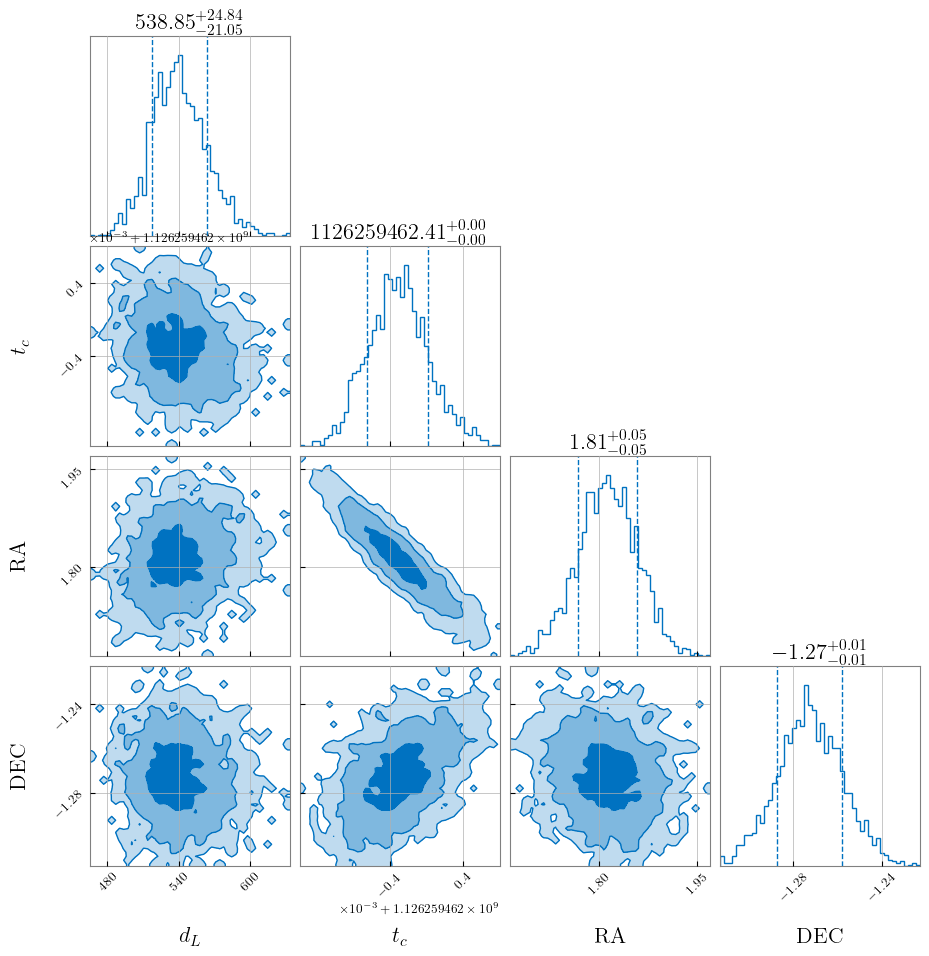

In [14]:
# IO settings
label = 'GW150914_quick_ext_pe_maxL_xphm'
pe_outdir = Path('./outdir_' + label)
pe_outdir.mkdir(exist_ok=True)

extrinsic_priors = deepcopy(priors)
extrinsic_priors['luminosity_distance'] = PowerLaw(2, 50, 2000, name='luminosity_distance')
# extrinsic_priors['psi'] = Uniform(0, np.pi, name='psi')

# 4. Initialise the GW likelihood
ext_likelihood = SimpleExtrinsicGWTransient(pe_ifos, wfm_gen, priors=extrinsic_priors, 
                                            reference_parameters=gw150914_maxL_parameters)

# # 5. Start the sampling process
simple_pe_result = run_sampler(
    ext_likelihood,
    extrinsic_priors, sampler='dynesty',
    outdir=pe_outdir, label=label,
    nlive=512, npool=1,
    conversion_function=generate_all_bbh_parameters,
    result_class=CBCResult
)

plt.rcParams.update({'figure.constrained_layout.use': False})
simple_pe_result.plot_corner()

### Quick injection test

16:31 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


16:31 bilby INFO    : Injected signal in H1:
16:31 bilby INFO    :   optimal SNR = 41.80
16:31 bilby INFO    :   matched filter SNR = 41.80+0.00j
16:31 bilby INFO    :   total_mass = 66.0
16:31 bilby INFO    :   mass_ratio = 0.8571428571428571
16:31 bilby INFO    :   a_1 = 0.4
16:31 bilby INFO    :   a_2 = 0.3
16:31 bilby INFO    :   tilt_1 = 0.5
16:31 bilby INFO    :   tilt_2 = 1.0
16:31 bilby INFO    :   phi_12 = 1.7
16:31 bilby INFO    :   phi_jl = 0.3
16:31 bilby INFO    :   luminosity_distance = 470.0
16:31 bilby INFO    :   theta_jn = 2.4
16:31 bilby INFO    :   psi = 2.65
16:31 bilby INFO    :   phase = 1.3
16:31 bilby INFO    :   geocent_time = 1126259462.4
16:31 bilby INFO    :   ra = 1.375
16:31 bilby INFO    :   dec = -1.2108
16:31 bilby INFO    : Injected signal in L1:
16:31 bilby INFO    :   optimal SNR = 33.58
16:31 bilby INFO    :   matched filter SNR = 33.58-0.00j
16:31 bilby INFO    :   total_mass = 66.0
16:31 bilby INFO    :   mass_ratio = 0.8571428571428571
16:31 bil

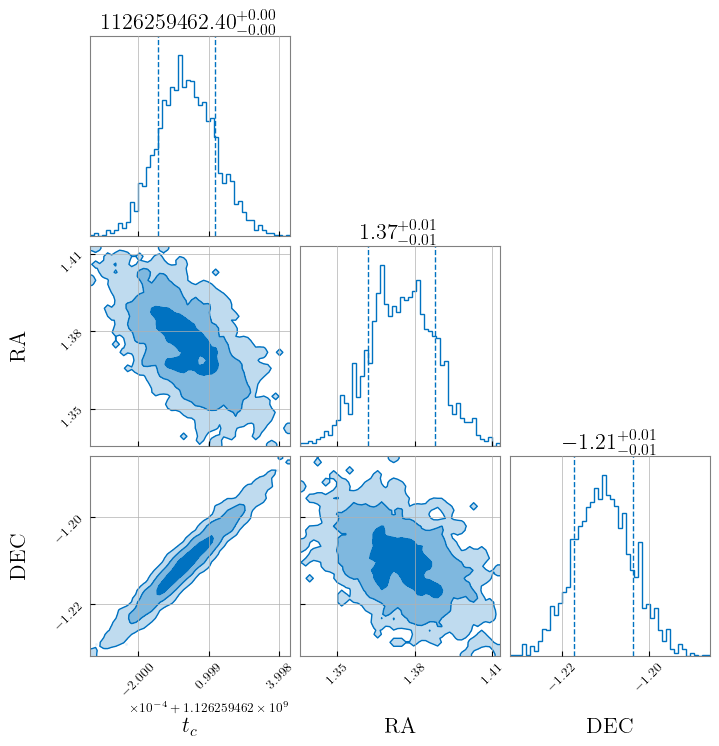

In [15]:
# IO settings
label = 'Inj_quick_ext_pe_xphm'
pe_outdir = Path('./outdir_' + label)
pe_outdir.mkdir(exist_ok=True)

# Data conditioning
trigger_time = 1126259462.4
sampling_frequency = 1024
maximum_frequency = 512
minimum_frequency = 20

wfm_gen = WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=lal_binary_black_hole,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=dict(
        waveform_approximant="IMRPhenomXPHM",
        reference_frequency=reference_frequency
    ),
)

set_strain_kwargs = dict(sampling_frequency=sampling_frequency, duration=duration, start_time=trigger_time - 2)
inject_kwargs = dict(waveform_generator=wfm_gen, parameters=gw150914_parameters)

ifos = InterferometerList(['H1', 'L1'])
for ifo in ifos:
    if ifo.name == 'V1':
        ifo.power_spectral_density = PowerSpectralDensity(asd_file=O4_sens[1])
    else:
        ifo.power_spectral_density = PowerSpectralDensity(asd_file=O4_sens[0])

# Zero-noise
ifos.set_strain_data_from_zero_noise(**set_strain_kwargs)
ifos.inject_signal(**inject_kwargs)

prior_dict = gw150914_parameters.copy()
prior_dict.update(
    {
        'ra': Uniform(0, np.pi, name='ra'),
        'dec': Cosine(name='dec'),
        'geocent_time': Uniform(trigger_time-0.1, trigger_time+0.1, name='geocent_time')
    }
)
priors = BBHPriorDict(prior_dict)

# 4. Initialise the GW likelihood
# likelihood = GravitationalWaveTransient(ifos, wfm_gen, priors=priors)
ext_likelihood = SimpleExtrinsicGWTransient(ifos, wfm_gen, priors=priors, 
                                            reference_parameters=gw150914_parameters)

# # 5. Start the sampling process
simple_pe_result = run_sampler(
    # likelihood, 
    ext_likelihood,
    priors, sampler='dynesty',
    outdir=pe_outdir, label=label,
    nlive=512, npool=1,
    conversion_function=generate_all_bbh_parameters,
    result_class=CBCResult
)
simple_pe_result.plot_corner()